# Data Science Fundamentals Assessment

This notebook demonstrates Python basics, statistics, data types, data cleaning, grouping, correlation, and visualization using an illustrative order dataset.

## 1. Python fundamentals
Variables store values. Conditional statements make decisions, loops repeat work, and functions package reusable logic.

In [52]:
student_name = "Asha"
study_hours = 4.5
completed_tasks = 3
is_submitted = True

print(student_name, study_hours, completed_tasks, is_submitted)

score = 78
if score >= 75:
    grade = "A"
elif score >= 60:
    grade = "B"
elif score >= 40:
    grade = "C"
else:
    grade = "Needs improvement"
print("Grade:", grade)


Asha 4.5 3 True
Grade: A


In [53]:
def calculate_average(values):
    if not values:
        raise ValueError("values must not be empty")
    return sum(values) / len(values)

scores = [70, 82, 91]
coordinates = (16.85, 74.58)
student = {"name": "Asha", "score": 82}
unique_scores = set(scores)

print("Average:", calculate_average(scores))
print("Tuple:", coordinates)
print("Dictionary:", student)
print("Set:", unique_scores)


Average: 81.0
Tuple: (16.85, 74.58)
Dictionary: {'name': 'Asha', 'score': 82}
Set: {82, 91, 70}


## 2. Descriptive statistics
The following sample delivery times are in days. The variance and standard deviation below use sample formulas.

In [54]:
from statistics import mean, median, multimode, variance, stdev

delivery_days = [2, 3, 3, 4, 8]
print("Mean:", mean(delivery_days))
print("Median:", median(delivery_days))
print("Mode:", multimode(delivery_days))
print("Sample variance:", variance(delivery_days))
print("Sample standard deviation:", stdev(delivery_days))


Mean: 4
Median: 3
Mode: [3]
Sample variance: 5.5
Sample standard deviation: 2.345207879911715


## 3. Load and inspect data
The CSV is a small synthetic dataset prepared for this assignment. It does not contain real customer records.

In [55]:
from pathlib import Path
import pandas as pd

# This path works when the notebook is run from the project root.
data_path = Path("data/sample_data.csv")
if not data_path.exists():
    data_path = Path("../data/sample_data.csv")

df = pd.read_csv(data_path)
df["order_date"] = pd.to_datetime(df["order_date"], errors="coerce")
print(df.head())
print("\nData types:\n", df.dtypes)
print("\nMissing values:\n", df.isna().sum())
print("\nNumeric summary:\n", df.select_dtypes(include="number").describe())


   order_id region     category  orders  delivery_days  customer_rating  \
0      1001  North  Electronics      12            3.2              4.5   
1      1002  South      Grocery      18            4.1              4.0   
2      1003  North     Clothing       9            2.8              4.7   
3      1004   West      Grocery      15            5.0              3.8   
4      1005   East  Electronics      11            3.6              4.2   

  order_date  
0 2026-01-05  
1 2026-01-06  
2 2026-01-07  
3 2026-01-08  
4 2026-01-09  

Data types:
 order_id                    int64
region                        str
category                      str
orders                      int64
delivery_days             float64
customer_rating           float64
order_date         datetime64[us]
dtype: object

Missing values:
 order_id           0
region             0
category           0
orders             0
delivery_days      0
customer_rating    0
order_date         0
dtype: int64

Numeric summar

## 4. Data cleaning and grouped analysis
A duplicate check is included. If values are missing, investigate why before choosing a treatment.

In [56]:
df = df.drop_duplicates()

region_summary = df.groupby("region", as_index=False).agg(
    total_orders=("orders", "sum"),
    average_delivery_days=("delivery_days", "mean"),
    average_customer_rating=("customer_rating", "mean"),
)
region_summary


,region,total_orders,average_delivery_days,average_customer_rating
0,East,44,3.200000,4.533333
1,North,37,3.166667,4.500000
2,South,35,5.233333,3.733333
3,West,37,4.700000,3.966667


## 5. Correlation
Correlation summarizes linear association between numerical variables. It does not prove that one variable causes another.

In [57]:
correlation = df[["orders", "delivery_days", "customer_rating"]].corr()
correlation


,orders,delivery_days,customer_rating
orders,1.000000,-0.429030,0.382035
delivery_days,-0.429030,1.000000,-0.967422
customer_rating,0.382035,-0.967422,1.000000


## 6. Visualization

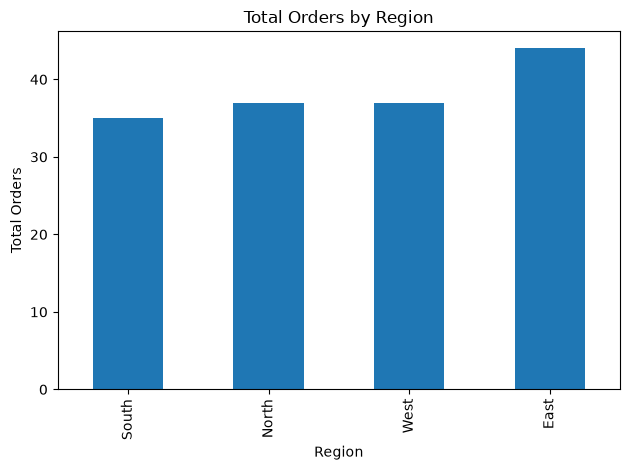

In [58]:
import matplotlib.pyplot as plt

region_totals = df.groupby("region")["orders"].sum().sort_values()
region_totals.plot(kind="bar")
plt.title("Total Orders by Region")
plt.xlabel("Region")
plt.ylabel("Total Orders")
plt.tight_layout()
plt.show()


## 7. Findings and limitations
- Grouped summaries compare order totals and average delivery duration by region.
- Descriptive statistics summarize the example delivery-time values.
- Correlation can show association but cannot establish causation.
- The dataset is small and synthetic, so results are for learning only and should not be generalized.

## 8. Reflection
After running the notebook, write a short reflection in your own words: What did you learn? What cleaning choices did you make? Which result surprised you? What additional data would improve the analysis?